In [5]:
import os
import shutil
import stat
from pathlib import Path

BASE_DIR = Path('../data/aptos')
target_splits = ['val_images', 'test_images']

def handle_remove_readonly(func, path, exc_info):
    """Clear Windows read-only flags so rmtree can delete directories."""
    os.chmod(path, stat.S_IWRITE)
    func(path)

for split in target_splits:
    split_dir = BASE_DIR / split
    if not split_dir.exists():
        print(f"Directory {split_dir} does not exist. Skipping...")
        continue

    # 1. Recursively find and move all nested PNGs to split_dir root
    all_pngs = list(split_dir.glob('**/*.png'))
    moved_count = 0
    for img in all_pngs:
        if img.parent != split_dir:
            target_path = split_dir / img.name
            shutil.move(str(img), str(target_path))
            moved_count += 1

    print(f"Moved {moved_count} images out of subfolders in {split}")

    # 2. Delete the empty nested subdirectories
    for item in split_dir.iterdir():
        if item.is_dir():
            try:
                shutil.rmtree(item, onexc=handle_remove_readonly)
            except Exception as e:
                print(f"Could not delete folder {item.name}: {e}")

print("\n--- Final Image Counts ---")
for split in ['train_images', 'val_images', 'test_images']:
    p = BASE_DIR / split
    if p.exists():
        count = len([f for f in os.listdir(p) if f.endswith('.png')])
        print(f"{split}: {count} PNGs")

Directory ..\data\aptos\val_images does not exist. Skipping...
Directory ..\data\aptos\test_images does not exist. Skipping...

--- Final Image Counts ---


In [6]:
import pandas as pd
import os

TRAIN_CSV = '../data/raw/aptos/train_1.csv'
VAL_CSV   = '../data/raw/aptos/valid.csv'
TEST_CSV  = '../data/raw/aptos/test.csv'

TRAIN_DIR = '../data/raw/aptos/train_images'
VAL_DIR   = '../data/raw/aptos/val_images'
TEST_DIR  = '../data/raw/aptos/test_images'
EXT = '.png'

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("Train:", train_df.shape, "| Val:", val_df.shape, "| Test:", test_df.shape)
train_df.head()

Train: (2930, 2) | Val: (366, 2) | Test: (366, 2)


,id_code,diagnosis
0,1ae8c165fd53,2
1,1b329a127307,1
2,1b32e1d775ea,4
3,1b3647865779,0
4,1b398c0494d1,0


In [7]:
def check_images_exist(df, img_dir, ext=EXT):
    missing = [f for f in df['id_code'] if not os.path.exists(os.path.join(img_dir, f + ext))]
    print(f"{img_dir}: {len(df) - len(missing)}/{len(df)} found, {len(missing)} missing")
    if missing:
        print("  sample missing:", missing[:5])
    return missing

check_images_exist(train_df, TRAIN_DIR)
check_images_exist(val_df, VAL_DIR)
check_images_exist(test_df, TEST_DIR)

../data/raw/aptos/train_images: 2918/2930 found, 12 missing
  sample missing: ['2.3255E+11', '2.93E+10', '3.89552E+11', '4.41118E+11', '5.35683E+11']
../data/raw/aptos/val_images: 364/366 found, 2 missing
  sample missing: ['7.10E+10', '1.94E+14']
../data/raw/aptos/test_images: 366/366 found, 0 missing


[]

In [6]:
%pip install matplotlib pandas

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 1.6 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/9.3 MB 1.6 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.3 MB 1.5 MB/s eta 0:00:06
   ------- -------------------------------- 1.8/9.3 MB 1.7 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/9.3 MB 1.7 MB/s eta 0:00:05
   ----------- ---------------------------- 2.6/9.3 MB 1.7 MB/s eta 0:00:05
   ------------ --------------------------- 2.9/9.3 MB 1.7 MB/s eta 0:00:04
   -------------- ------------------------- 3.4/9.3 MB 1.7 MB/s eta 0:00:04
   ---------------- ----------------------- 3.9/9.3 MB 1.8 MB/s eta 0:00:03
   ------------------- -------------------- 4.5/


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


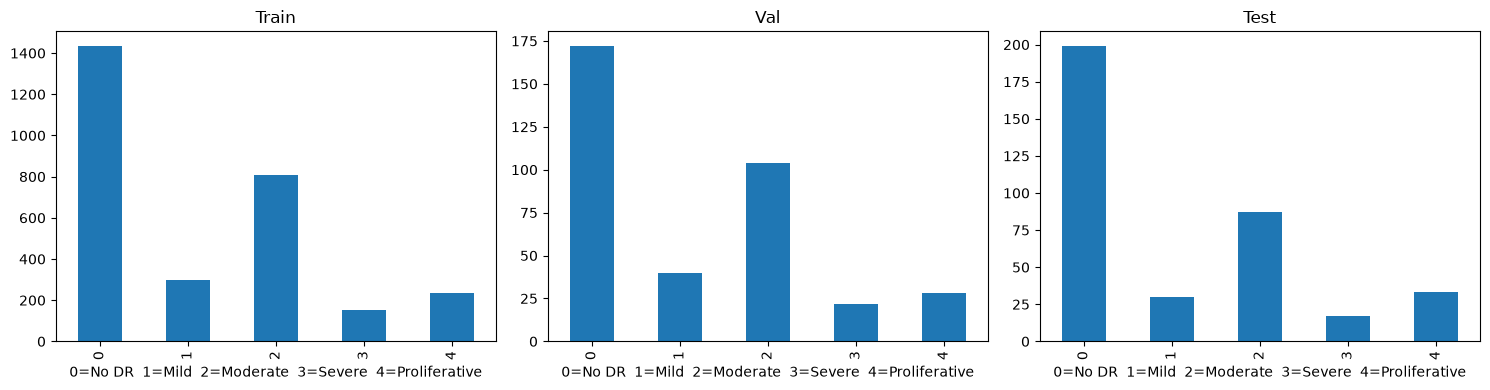

diagnosis
0    0.489420
1    0.102389
2    0.275768
3    0.052560
4    0.079863
Name: proportion, dtype: float64


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, df, name in zip(axes, [train_df, val_df, test_df], ['Train', 'Val', 'Test']):
    df['diagnosis'].value_counts().sort_index().plot(kind='bar', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('0=No DR  1=Mild  2=Moderate  3=Severe  4=Proliferative')
plt.tight_layout()
plt.show()

print(train_df['diagnosis'].value_counts(normalize=True).sort_index())


In [8]:
import sys
!{sys.executable} -m pip install torch torchvision opencv-python-headless albumentations pytorch-grad-cam scikit-learn seaborn

ERROR: Could not find a version that satisfies the requirement pytorch-grad-cam (from versions: none)

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for pytorch-grad-cam


In [10]:
%pip install opencv-python

  Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/44.0 MB 858.3 kB/s eta 0:00:51
    --------------------------------------- 0.8/44.0 MB 855.9 kB/s eta 0:00:51
    --------------------------------------- 0.8/44.0 MB 855.9 kB/s eta 0:00:51
    --------------------------------------- 1.0/44.0 MB 837.0 kB/s eta 0:00:52
    --------------------------------------- 1.0/44.0 MB 837.0 kB/s eta 0:00:52
   - -------------------------------------- 1.3/44.0 MB 757.5 kB/s eta 0:00:57
   - -------------------------------------- 1.3/44.0 MB 757.5 kB/s eta 0:00:57
   - -------------------------------------- 1.6/44.0 MB 738.7 kB/s eta 0:00:58
   - -------------------------------------- 1.8/44.0 MB 753.1 kB/s eta 0:00:56



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


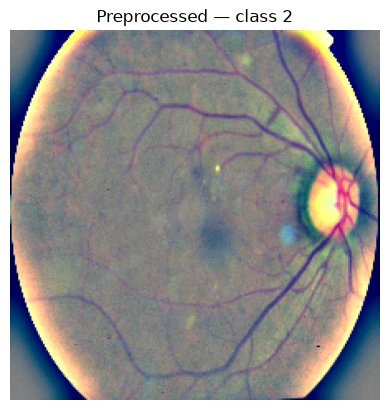

In [9]:
import cv2
import numpy as np

IMG_SIZE = 224

def crop_image_from_gray(img, tol=7):
    """Crop away the black border around the retina."""
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask = gray_img > tol
    if mask.sum() == 0:  # image too dark to crop safely
        return img
    check_shape = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))].shape[0]
    if check_shape == 0:
        return img
    channels = [img[:, :, i][np.ix_(mask.any(1), mask.any(0))] for i in range(3)]
    return np.stack(channels, axis=-1)

def preprocess_retina_image(img_path, img_size=IMG_SIZE, sigmaX=10):
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = crop_image_from_gray(img)
    img = cv2.resize(img, (img_size, img_size))
    img = cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0, 0), sigmaX), -4, 128)
    return img

# Sanity check
sample_row = train_df.iloc[0]
sample_path = os.path.join(TRAIN_DIR, sample_row['id_code'] + EXT)
processed = preprocess_retina_image(sample_path)
plt.imshow(processed)
plt.title(f"Preprocessed — class {sample_row['diagnosis']}")
plt.axis('off')
plt.show()

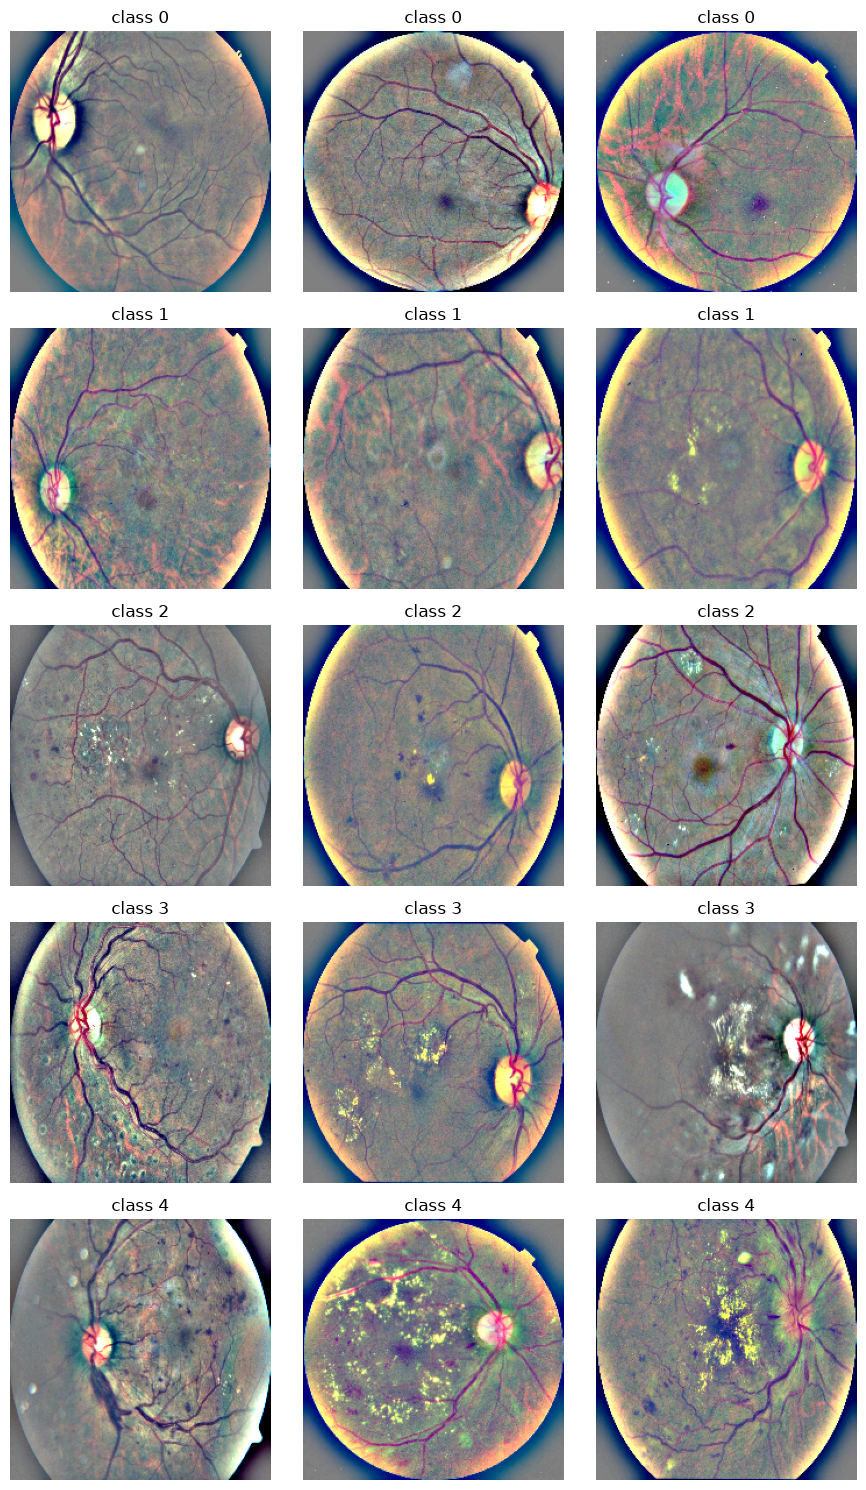

In [10]:
def show_samples_per_class(df, img_dir, n=3):
    classes = sorted(df['diagnosis'].unique())
    fig, axes = plt.subplots(len(classes), n, figsize=(n * 3, len(classes) * 3))
    for i, c in enumerate(classes):
        sample_ids = df[df['diagnosis'] == c]['id_code'].sample(n, random_state=42).values
        for j, id_code in enumerate(sample_ids):
            img = preprocess_retina_image(os.path.join(img_dir, id_code + EXT))
            axes[i, j].imshow(img)
            axes[i, j].set_title(f"class {c}")
            axes[i, j].axis('off')
    plt.tight_layout()
    plt.show()

show_samples_per_class(train_df, TRAIN_DIR)

In [15]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import torch
from torch.utils.data import Dataset, DataLoader

class RetinopathyDataset(Dataset):
    def __init__(self, df, img_dir, img_size=IMG_SIZE, ext=EXT, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.img_size = img_size
        self.ext = ext
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['id_code'] + self.ext)
        img = preprocess_retina_image(img_path, self.img_size)

        if self.transform:
            img = self.transform(image=img)['image']
        else:
            img = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0

        label = torch.tensor(row['diagnosis'], dtype=torch.long)
        return img, label

In [3]:
%pip install --user albumentations

  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
  Using cached pydantic-2.13.5-py3-none-any.whl.metadata (110 kB)
  Using cached albucore-0.0.24-py3-none-any.whl.metadata (5.3 kB)
  Using cached opencv_python_headless-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached annotated_types-0.8.0-py3-none-any.whl.metadata (15 kB)
Using cached albumentations-2.0.8-py3-none-any.whl (369 kB)
Using cached albucore-0.0.24-py3-none-any.whl (15 kB)
Using cached opencv_python_headless-5.0.0.93-cp37-abi3-win_amd64.whl (43.8 MB)
Using cached pydantic-2.13.5-py3-none-any.whl (472 kB)
Using cached annotated_types-0.8.0-py3-none-any.whl (13 kB)

   ---------------------------------------- 0/5 [opencv-python-headless]
   ---------------------------------------- 0/5 [opencv-python-headless]
   ---------------------------------------- 0/5 [opencv-python-headless]
   ---------------------------------------- 0/5 [opencv-python-headless]
   -----------------------------------


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

train_dataset = RetinopathyDataset(train_df, TRAIN_DIR, transform=train_transform)
val_dataset   = RetinopathyDataset(val_df, VAL_DIR, transform=eval_transform)
test_dataset  = RetinopathyDataset(test_df, TEST_DIR, transform=eval_transform)

print(len(train_dataset), len(val_dataset), len(test_dataset))

2930 366 366


In [16]:
from torch.utils.data import WeightedRandomSampler

class_counts = train_df['diagnosis'].value_counts().sort_index().values
class_weights = 1.0 / class_counts
sample_weights = train_df['diagnosis'].map(lambda c: class_weights[c]).values

sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

BATCH_SIZE = 16  
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Class weights:", dict(enumerate(class_weights.round(4))))

Class weights: {0: np.float64(0.0007), 1: np.float64(0.0033), 2: np.float64(0.0012), 3: np.float64(0.0065), 4: np.float64(0.0043)}


In [ ]:
import torch.nn as nn
from torchvision import models

device = torch.device('cpu')
print("Using device:", device)

def build_model(num_classes=5):
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)

    for param in model.parameters():
        param.requires_grad = False
    for param in model.features[-3:].parameters():
        param.requires_grad = True

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model.to(device)

model = build_model()

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {n_trainable:,} / {n_total:,}")

Using device: cpu
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\hi/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:04<00:00, 2.40MB/s]


Trainable params: 649,765 / 1,522,981


In [18]:
import torch.optim as optim

weights_tensor = torch.tensor(class_weights / class_weights.sum() * len(class_weights), dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

In [19]:
from sklearn.metrics import cohen_kappa_score, f1_score
import copy, time

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    f1 = f1_score(all_labels, all_preds, average='macro')
    return kappa, f1, all_labels, all_preds

EPOCHS = 10
PATIENCE = 3  
best_kappa = -1
best_state = None
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    start = time.time()
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)

    train_loss = running_loss / len(train_dataset)
    val_kappa, val_f1, _, _ = evaluate(model, val_loader)
    scheduler.step(val_kappa)
    elapsed = time.time() - start

    print(f"Epoch {epoch+1}/{EPOCHS} | loss={train_loss:.4f} | val_kappa={val_kappa:.4f} | val_macro_f1={val_f1:.4f} | {elapsed:.0f}s")

    if val_kappa > best_kappa:
        best_kappa = val_kappa
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
        print(f"  -> new best (kappa={best_kappa:.4f})")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f"  -> no improvement for {PATIENCE} epochs, stopping early")
            break

model.load_state_dict(best_state)
print(f"\nBest val quadratic weighted kappa: {best_kappa:.4f}")

RuntimeError: stack expects each tensor to be equal size, but got [3, 2588, 3388] at entry 0 and [3, 1536, 2048] at entry 1